In [1]:
import numpy as np
import matplotlib.pyplot as plt

from plotsetup import *

### Phyllotaxis (sunflower) pattern

Let the golden angle be

$$
\phi = \pi(3-\sqrt{5}).
$$

For $n=1,\ldots,N$, define the points

$$
\mathbf{x}_n
=
\sqrt{\frac{n}{N}}
\begin{pmatrix}
\cos(n\phi) \\
\sin(n\phi)
\end{pmatrix}.
$$

Equivalently,

$$
x_{1,n} = \sqrt{\frac{n}{N}}\cos(n\phi),
\qquad
x_{2,n} = \sqrt{\frac{n}{N}}\sin(n\phi).
$$

The factor $\sqrt{n/N}$ distributes the points approximately uniformly over the unit disk, while successive points are separated by the golden angle

$$
\phi \approx 2.39996 \text{ rad} \approx 137.508^\circ.
$$

Under a linear transformation $A\in\mathbb{R}^{2\times2}$, the transformed points are simply

$$
\mathbf{y}_n = A\mathbf{x}_n.
$$

In [2]:
# define a bunch of points: phyllotaxis pattern

n_points = 200
points = []

for n in range(n_points):
    r = np.sqrt(n) / 10
    theta = n * (np.pi * (3 - np.sqrt(5)))
    x1 = r * np.cos(theta)
    x2 = r * np.sin(theta)
    point = [x1, x2]
    points.append(point)

points = np.array(points).T



In [3]:
print(points.shape)

print(points[:, :4])


(2, 200)
[[ 0.         -0.07373689  0.01236386  0.1053847 ]
 [ 0.          0.06754903 -0.14087986  0.13745568]]


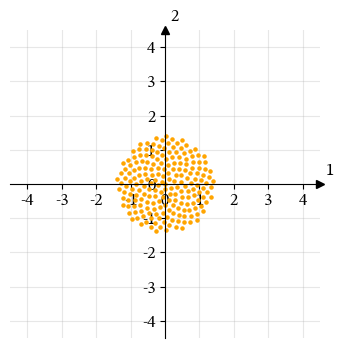

In [4]:
fig, ax = new_plot()
x1 = points[0]
x2 = points[1]
ax.scatter(x1, x2, color='orange', s=5)


<Axes: >

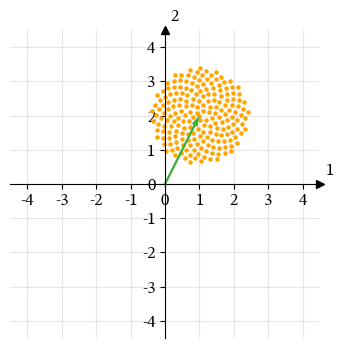

In [5]:
# move the points
fig, ax = new_plot()
y = np.array([1,2])
x1 = x1 + y[0]
x2 = x2 + y[1]
ax.scatter(x1, x2, color='orange', s=5)
draw_vector(ax, y)


In [8]:
# define a linear transformation

A = np.array([[2, 1], 
              [0, 1]])

# transform the points 

points_transformed = A @ points


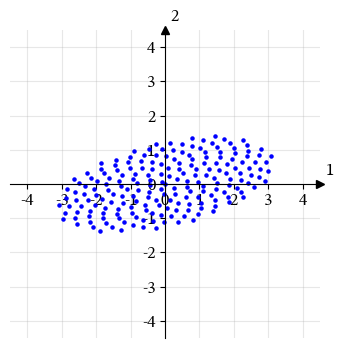

In [9]:
fig, ax = new_plot()

ax.scatter(points_transformed[0], points_transformed[1], color='blue', s=5)


In [10]:
# define a nonlinear transformation

def nonlin_map(x):
    """ Transform x -> x^2 as if x was a complex number."""
    
    x1 = x[0]
    x2 = x[1]
    y1 = x1**2 - x2**2
    y2 = 2*x1*x2 
    y = np.array([y1, y2])
    return y

In [11]:
points2 = np.zeros_like(points)
for i in range(points.shape[1]):
    points2[:,i] = nonlin_map(points[:,i])

print(points2[:,:20])

[[ 0.          0.00087426 -0.01969427 -0.00778813  0.03757285  0.0211923
  -0.05191267 -0.04025906  0.06117192  0.06379465 -0.06407091 -0.09029442
   0.0596617   0.11801285 -0.04738332 -0.1450455   0.02710019  0.16941956
   0.00087809 -0.18918921]
 [ 0.         -0.00996171 -0.00348364  0.02897145  0.01372155 -0.04528671
  -0.03008445  0.05726437  0.05155576 -0.06348419 -0.07677837  0.0628245
   0.10411763 -0.05452493 -0.1317377   0.03823353  0.15768824 -0.01403606
  -0.17999786 -0.01753401]]


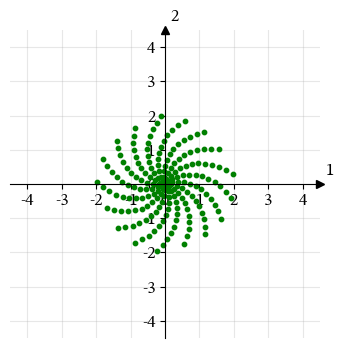

In [12]:
fig, ax = new_plot()

ax.scatter(points2[0], points2[1], color='green', s=10)
